In [22]:
import torch 
import torch.nn as nn 
import torch.nn.functional as f

from torchvision import datasets, transforms
from torch.utils.data import DataLoader

from torch.optim import Adam 

In [23]:
"""ACTUAL TRAINING CODE"""
device = torch.device('mps' if torch.backends.mps.is_available() else 'cpu')

# Train Function 
def train_batch(x, y, model, opt, loss_fn):
    model.train() 

    opt.zero_grad()
    batch_loss = loss_fn(model(x), y)
    batch_loss.backward()
    opt.step()

    return batch_loss.detach().cpu().numpy()

# Evaluation function
@torch.no_grad()
def accuracy(x, y, model):
    model.eval() 

    prediction = model(x) 
    argmaxes = prediction.argmax(dim=1)
    s = torch.sum((argmaxes == y).float())/len(y)
    return s.detach().cpu().numpy()

## Models

In [24]:
from torchvision import models
vgg16 = models.vgg16(weights=models.VGG16_Weights.IMAGENET1K_V1)

for param in vgg16.features.parameters():
    param.requires_grad = False

vgg16.avgpool = nn.AdaptiveAvgPool2d(output_size=(1, 1))
vgg16.classifier = nn.Sequential(
    nn.Flatten(),
    nn.Linear(512, 128), 
    nn.ReLU(), 
    nn.Dropout(0.2),
    nn.Linear(128, 10))

print(vgg16)


VGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU(inplace=True)
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU(inplace=True)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (15): ReLU(inplace=True)
    (16): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1

In [25]:
from torchvision import models
vgg19 = models.vgg19(weights=models.VGG19_Weights.IMAGENET1K_V1)

for param in vgg19.features.parameters():
    param.requires_grad = False

vgg19.avgpool = nn.AdaptiveAvgPool2d(output_size=(1, 1))
vgg19.classifier = nn.Sequential(
    nn.Flatten(),
    nn.Linear(512, 128), 
    nn.ReLU(), 
    nn.Dropout(0.2),
    nn.Linear(128, 10))

print(vgg19)


VGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU(inplace=True)
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU(inplace=True)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (15): ReLU(inplace=True)
    (16): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padd

In [26]:
from torchvision import models
resnet18 = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)

for param in resnet18.parameters():
    param.requires_grad = False

resnet18.fc = nn.Linear(512, 10)

print(resnet18)



ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [27]:
from torchvision import models
resnet34 = models.resnet34(weights=models.ResNet34_Weights.IMAGENET1K_V1)

for param in resnet34.parameters():
    param.requires_grad = False

resnet34.fc = nn.Linear(512, 10)

print(resnet34)


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

### Dataset

In [31]:
CIFAR10_MEAN = (0.4914, 0.4822, 0.4465)
CIFAR10_STD = (0.2470, 0.2435, 0.2616)
trainTransforms = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=CIFAR10_MEAN, std=CIFAR10_STD)
])

testTransforms = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=CIFAR10_MEAN, std=CIFAR10_STD)
])
       
        # Load Datasets
data_path = "./Datasets"


train_data = datasets.CIFAR10(root=data_path, train=True, download=True, transform=trainTransforms)
test_data = datasets.CIFAR10(root=data_path, train=False, download=True, transform=testTransforms)

train_loader = DataLoader(
    dataset = train_data, 
    batch_size = 16, 
    shuffle = True)

test_loader = DataLoader(
    dataset = train_data, 
    batch_size = 16, 
    shuffle = False)

        

In [ ]:


vgg16 = vgg16.to(device)
loss_func = nn.CrossEntropyLoss()
optimizer = Adam(vgg16.parameters(), lr=1e-3)
n_epochs = 5

total_params = sum(p.numel() for p in vgg16.parameters())
print(f"Total parameters: {total_params}")

# Training Loop 
import numpy as np 
vgg16_losses, vgg16_accuracies, n_epochs = [], [], 5 

for epoch in range(n_epochs):
    print(f"Running epoch {epoch+1} of {n_epochs}")

    # Train
    epoch_losses, epoch_accuracies = [], []
    for batch in train_loader: 
        x, y = batch 
        x = x.to(device)
        y = y.to(device)
        batch_loss = train_batch(x, y, vgg16, optimizer, loss_func)
        epoch_losses.append(batch_loss)
    epoch_loss = np.mean(epoch_losses)

    # Evaluate
    for batch in test_loader: 
        x, y = batch 
        x = x.to(device)
        y = y.to(device)
        batch_acc = accuracy(x, y, vgg16)
        epoch_accuracies.append(batch_acc)
    epoch_acc = np.mean(epoch_accuracies)

    vgg16_losses.append(epoch_loss)
    vgg16_accuracies.append(epoch_acc)



# Plotting 
import matplotlib.pyplot as plt
plt.figure(figsize=(13, 3))
plt.subplot(121) 
plt.title("Training Loss value over epochs")
plt.plot(np.arange(n_epochs) + 1, vgg16_losses)
plt.subplot(122)
plt.title("Training Accuracy value over epochs")
plt.plot(np.arange(n_epochs) + 1, vgg16_accuracies)
plt.show()


# Testing on test set 
vgg16_test_acc = [] 
for batch in test_loader: 
    x, y = batch 
    x = x.to(device)
    y = y.to(device)
    batch_acc = accuracy(x, y, vgg16)
    vgg16_test_acc.append(batch_acc)
print(f"Test accuracy: {np.mean(vgg16_test_acc)}")



Total parameters: 14781642
Running epoch 1 of 5


KeyboardInterrupt: 

In [ ]:
vgg19 = vgg19.to(device)
loss_func = nn.CrossEntropyLoss()
optimizer = Adam(vgg19.parameters(), lr=1e-3)
n_epochs = 5

total_params = sum(p.numel() for p in vgg19.parameters())
print(f"Total parameters: {total_params}")

# Training Loop 
import numpy as np 
vgg19_losses, vgg19_accuracies, n_epochs = [], [], 5 

for epoch in range(n_epochs):
    print(f"Running epoch {epoch+1} of {n_epochs}")

    # Train
    epoch_losses, epoch_accuracies = [], []
    for batch in train_loader: 
        x, y = batch 
        x = x.to(device)
        y = y.to(device)
        batch_loss = train_batch(x, y, vgg19, optimizer, loss_func)
        epoch_losses.append(batch_loss)
    epoch_loss = np.mean(epoch_losses)

    # Evaluate
    for batch in test_loader: 
        x, y = batch 
        x = x.to(device)
        y = y.to(device)
        batch_acc = accuracy(x, y, vgg19)
        epoch_accuracies.append(batch_acc)
    epoch_acc = np.mean(epoch_accuracies)

    vgg19_losses.append(epoch_loss)
    vgg19_accuracies.append(epoch_acc)



# Plotting 
import matplotlib.pyplot as plt
plt.figure(figsize=(13, 3))
plt.subplot(121) 
plt.title("Training Loss value over epochs")
plt.plot(np.arange(n_epochs) + 1, vgg19_losses)
plt.subplot(122)
plt.title("Training Accuracy value over epochs")
plt.plot(np.arange(n_epochs) + 1, vgg19_accuracies)
plt.show()


# Testing on test set 
vgg19_test_acc = [] 
for batch in test_loader: 
    x, y = batch 
    x = x.to(device)
    y = y.to(device)
    batch_acc = accuracy(x, y, vgg19)
    vgg19_test_acc.append(batch_acc)
print(f"Test accuracy: {np.mean(vgg19_test_acc)}")


In [ ]:


resnet18 = resnet18.to(device)
loss_func = nn.CrossEntropyLoss()
optimizer = Adam(resnet18.parameters(), lr=1e-3)
n_epochs = 5

total_params = sum(p.numel() for p in resnet18.parameters())
print(f"Total parameters: {total_params}")

# Training Loop 
import numpy as np 
resnet18_losses, resnet18_accuracies, n_epochs = [], [], 5 

for epoch in range(n_epochs):
    print(f"Running epoch {epoch+1} of {n_epochs}")

    # Train
    epoch_losses, epoch_accuracies = [], []
    for batch in train_loader: 
        x, y = batch 
        x = x.to(device)
        y = y.to(device)
        batch_loss = train_batch(x, y, resnet18, optimizer, loss_func)
        epoch_losses.append(batch_loss)
    epoch_loss = np.mean(epoch_losses)

    # Evaluate
    for batch in test_loader: 
        x, y = batch 
        x = x.to(device)
        y = y.to(device)
        batch_acc = accuracy(x, y, resnet18)
        epoch_accuracies.append(batch_acc)
    epoch_acc = np.mean(epoch_accuracies)

    resnet18_losses.append(epoch_loss)
    resnet18_accuracies.append(epoch_acc)



# Plotting 
import matplotlib.pyplot as plt
plt.figure(figsize=(13, 3))
plt.subplot(121) 
plt.title("Training Loss value over epochs")
plt.plot(np.arange(n_epochs) + 1, resnet18_losses)
plt.subplot(122)
plt.title("Training Accuracy value over epochs")
plt.plot(np.arange(n_epochs) + 1, resnet18_accuracies)
plt.show()


# Testing on test set 
resnet18_test_acc = [] 
for batch in test_loader: 
    x, y = batch 
    x = x.to(device)
    y = y.to(device)
    batch_acc = accuracy(x, y, resnet18)
    resnet18_test_acc.append(batch_acc)
print(f"Test accuracy: {np.mean(resnet18_test_acc)}")


In [ ]:
resnet34 = resnet34.to(device)
loss_func = nn.CrossEntropyLoss()
optimizer = Adam(resnet34.parameters(), lr=1e-3)
n_epochs = 5

total_params = sum(p.numel() for p in resnet34.parameters())
print(f"Total parameters: {total_params}")

# Training Loop 
import numpy as np 
resnet34_losses, resnet34_accuracies, n_epochs = [], [], 5 

for epoch in range(n_epochs):
    print(f"Running epoch {epoch+1} of {n_epochs}")

    # Train
    epoch_losses, epoch_accuracies = [], []
    for batch in train_loader: 
        x, y = batch 
        x = x.to(device)
        y = y.to(device)
        batch_loss = train_batch(x, y, resnet34, optimizer, loss_func)
        epoch_losses.append(batch_loss)
    epoch_loss = np.mean(epoch_losses)

    # Evaluate
    for batch in test_loader: 
        x, y = batch 
        x = x.to(device)
        y = y.to(device)
        batch_acc = accuracy(x, y, resnet34)
        epoch_accuracies.append(batch_acc)
    epoch_acc = np.mean(epoch_accuracies)

    resnet34_losses.append(epoch_loss)
    resnet34_accuracies.append(epoch_acc)



# Plotting 
import matplotlib.pyplot as plt
plt.figure(figsize=(13, 3))
plt.subplot(121) 
plt.title("Training Loss value over epochs")
plt.plot(np.arange(n_epochs) + 1, resnet34_losses)
plt.subplot(122)
plt.title("Training Accuracy value over epochs")
plt.plot(np.arange(n_epochs) + 1, resnet34_accuracies)
plt.show()

# Testing on test set 
resnet34_test_acc = [] 
for batch in test_loader: 
    x, y = batch 
    x = x.to(device)
    y = y.to(device)
    batch_acc = accuracy(x, y, resnet34)
    resnet34_test_acc.append(batch_acc)
print(f"Test accuracy: {np.mean(resnet34_test_acc)}")


## 3 image, data from google

In [49]:
from PIL import Image 
import numpy as np

imgs = ["boat1", "boat2", "car1", "car2", "frog1", "frog2"]
tensor_imgs = [] 
for img in imgs: 
    image_path = f"./images/{img}.jpeg"
    img = Image.open(image_path)

    img = torch.tensor(np.array(img)).permute(2, 0, 1).unsqueeze(0).float() / 255.0
    img = transforms.Normalize(mean=CIFAR10_MEAN, std=CIFAR10_STD)(img)
    img = img.to(device)
    tensor_imgs.append(img)

# resize all to 32 x 32 
resized_imgs = []
for img in tensor_imgs:
    resized_img = f.interpolate(img, size=(32, 32), mode='bilinear', align_corners=False)
    resized_imgs.append(resized_img)

for img in resized_imgs: 
    print(img.shape)

torch.Size([1, 3, 32, 32])
torch.Size([1, 3, 32, 32])
torch.Size([1, 3, 32, 32])
torch.Size([1, 3, 32, 32])
torch.Size([1, 3, 32, 32])
torch.Size([1, 3, 32, 32])


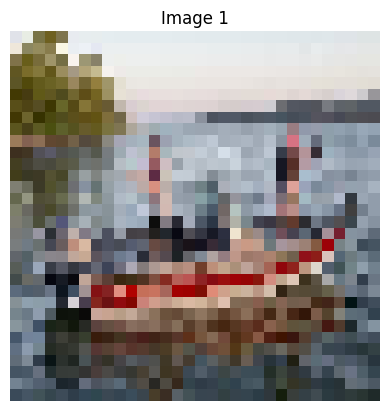

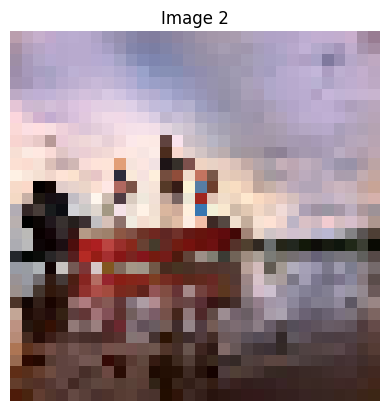

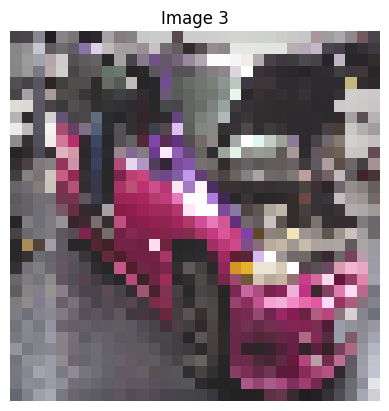

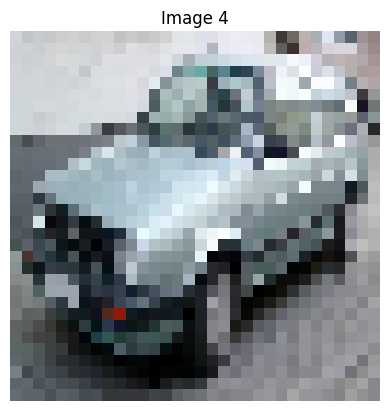

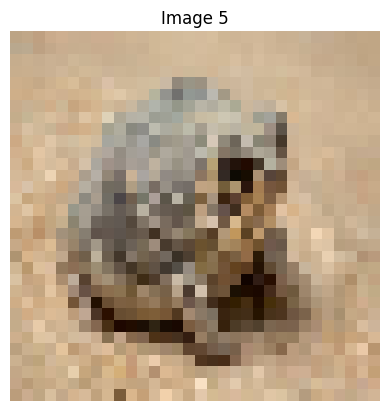

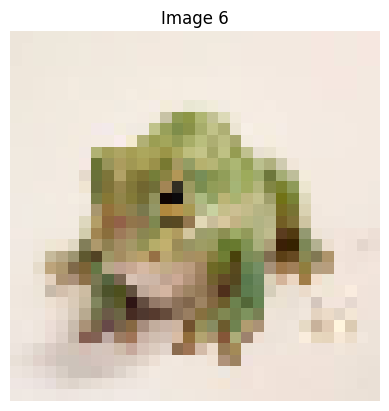

In [50]:
import matplotlib.pyplot as plt
for i, img in enumerate(resized_imgs):
    img = img.squeeze(0).permute(1, 2, 0).cpu().numpy()
    img = (img * np.array(CIFAR10_STD) + np.array(CIFAR10_MEAN)).clip(0, 1)
    plt.imshow(img)
    plt.title(f"Image {i+1}")
    plt.axis('off')
    plt.show()

In [ ]:
# Testing on the 6 images vgg16
for i, img in enumerate(resized_imgs):
    print("vgg16 prediction:")
    img = img.to(device)
    pred = vgg16(img)
    pred_label = pred.argmax(dim=1).item()
    print(f"Image {i+1} predicted label: {pred_label}")

    

In [ ]:
# Testing on the 6 images vgg19
for i, img in enumerate(resized_imgs):
    print("vgg19 prediction:")
    img = img.to(device)
    pred = vgg19(img)
    pred_label = pred.argmax(dim=1).item()
    print(f"Image {i+1} predicted label: {pred_label}")

    

In [ ]:
# Testing on the 6 images resnet18
for i, img in enumerate(resized_imgs):
    print("resnet18 prediction:")
    img = img.to(device)
    pred = resnet18(img)
    pred_label = pred.argmax(dim=1).item()
    print(f"Image {i+1} predicted label: {pred_label}")

    

In [ ]:
# Testing on the 6 images vgg19
for i, img in enumerate(resized_imgs):
    print("resnet34 prediction:")
    img = img.to(device)
    pred = resnet34(img)
    pred_label = pred.argmax(dim=1).item()
    print(f"Image {i+1} predicted label: {pred_label}")